# The Goal of EDA : Understand the data before any transformation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Displaying
pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

# Loading raw data
tx = pd.read_csv("../data/raw/train_transaction.csv")
idf = pd.read_csv("../data/raw/train_identity.csv")

# Merging on TransactionID (left join)
df = tx.merge(idf, on="TransactionID", how="left")

print(f"Transactions : {tx.shape}")
print(f"Identity    : {idf.shape}")
print(f"Merged     : {df.shape}")



Transactions : (590540, 394)
Identity    : (144233, 41)
Merged     : (590540, 434)


In [3]:
df.head()

print(f"Lignes : {df.shape[0]:,} | Colonnes : {df.shape[1]}")
print("\nRépartition des types :")
print(df.dtypes.value_counts())

df.describe()

Lignes : 590,540 | Colonnes : 434

Répartition des types :
float64    399
str         31
int64        4
Name: count, dtype: int64


,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,dist2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_13,id_14,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,238269.000000,37627.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,589271.000000,309743.000000,327662.000000,421618.000000,280699.000000,73187.000000,38917.000000,74926.000000,74926.000000,514518.000000,311253.000000,64717.000000,61952.000000,62187.000000,501427.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,...,589271.000000,589271.000000,589271.000000,590528.000000,590528.000000,590528.000000,590528.000000,590528.000000,590528.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.00000,82351.000000,82351.000000,82351.000000,82351.000000,144233.000000,140872.000000,66324.000000,66324.000000,136865.000000,136865.000000,5155.000000,5155.000000,74926.000000,74926.000000,140978.000000,127320.000000,80044.000000,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,118.502180,231.855423,14.092458,15.269734,0.005644,4.092185,5.571526,9.071082,2.848478,5.144574,4.480240,5.240343,10.241521,4.076227,32.539918,8.295215,94.347568,169.563231,28.343348,140.002441,42.335965,69.805717,41.638950,146.058108,0.561057,123.982137,146.621465,54.037533,17.901295,57.724444,163.744579,0.999945,1.045204,1.078075,0.846456,0.876991,1.045686,1.072870,1.027704,1.041529,...,21.351473,43.319174,26.806977,109.818544,247.606741,162.153398,18.372476,42.073133,28.326584,6.220289,13.103775,9.184612,0.058494,0.851040,0.296633,0.336790,1.312844,0.775874,721.741883,1375.783644,1014.622782,9.807015,59.16455,28.530903,55.352422,151.160542,100.700882,-10.170502,174716.584708,0.060189,-0.058938,1.615585,-6.698710,13.285354,-38.600388,0.091023,-0.301124,99.745325,48.053071,-344.507146,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,371.872026,529.053494,133.569018,154.668899,0.150536,68.848459,25.786976,71.508467,61.727304,95.378574,16.674897,95.581443,94.336292,86.666218,129.364844,49.544262,157.660387,177.315865,62.384721,191.096774,89.000144,143.669253,99.743264,231.663840,0.316880,182.615225,186.042622,124.274558,67.614425,136.312450,202.726660,0.007390,0.240133,0.320890,0.440053,0.475902,0.239385,0.304779,0.186069,0.226339,...,95.902970,173.619028,116.853222,2270.033202,3980.042828,2793.343636,332.304848,473.499307,382.053171,56.022561,106.739813,73.627893,0.304415,3.950295,1.364356,1.580144,8.769083,4.727971,6217.223583,11169.275702,7955.735482,243.861391,387.62948,274.576920,668.486833,1095.034387,814.946722,14.347949,159651.816856,0.598231,0.701015,5.249856,16.491104,11.384207,26.084899,0.983842,2.789446,1.127602,11.774858,93.695502,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000

Counting :
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate : 3.50 %
trusted/fraud Ratio : 27.6 pour 1


C:\Users\mamao\AppData\Local\Temp\ipykernel_17448\430525488.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels(["Trusted (0)", "Fraud (1)"])


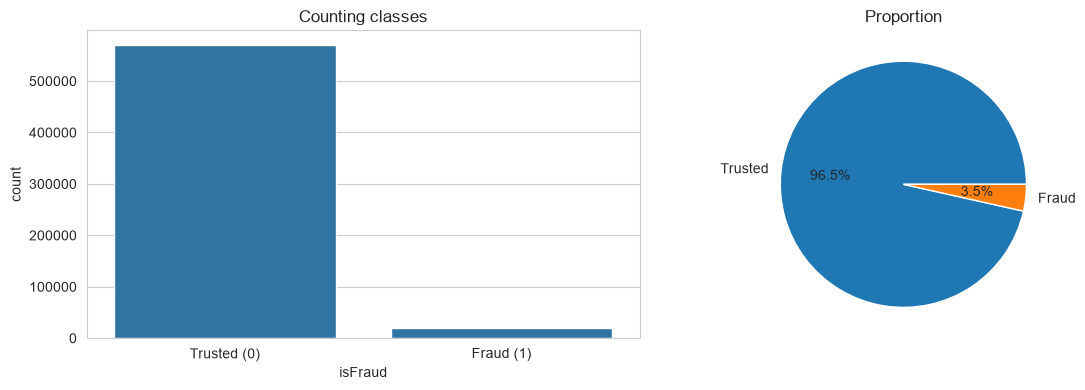

In [5]:
# Counting the pourcentage of each class in the label
counts = df["isFraud"].value_counts()
pct = df["isFraud"].value_counts(normalize=True) * 100

print("Counting :")
print(counts)
print(f"\nFraud rate : {pct[1]:.2f} %")
print(f"trusted/fraud Ratio : {counts[0]/counts[1]:.1f} pour 1")


fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="isFraud", data=df, ax=ax[0])
ax[0].set_title("Counting classes")
ax[0].set_xticklabels(["Trusted (0)", "Fraud (1)"])

df["isFraud"].value_counts(normalize=True).plot.pie(
    autopct="%1.1f%%", labels=["Trusted", "Fraud"], ax=ax[1]
)
ax[1].set_title("Proportion")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Notes
- Fraud represents 3.50% of transactions (which is a ratio of about 27.6 legitimate transactions for every 1 fraudulent one).
- Accuracy is therefore inappropriate as an evaluation metric; the project uses ROC-AUC, PR-AUC, and a custom business-cost metric, with threshold tuning driven by the asymmetric cost of false negatives versus false positives.

TransactionDT interval (secondes) :
  min : 86,400
  max : 15,811,131
  time covered : ~182 jours


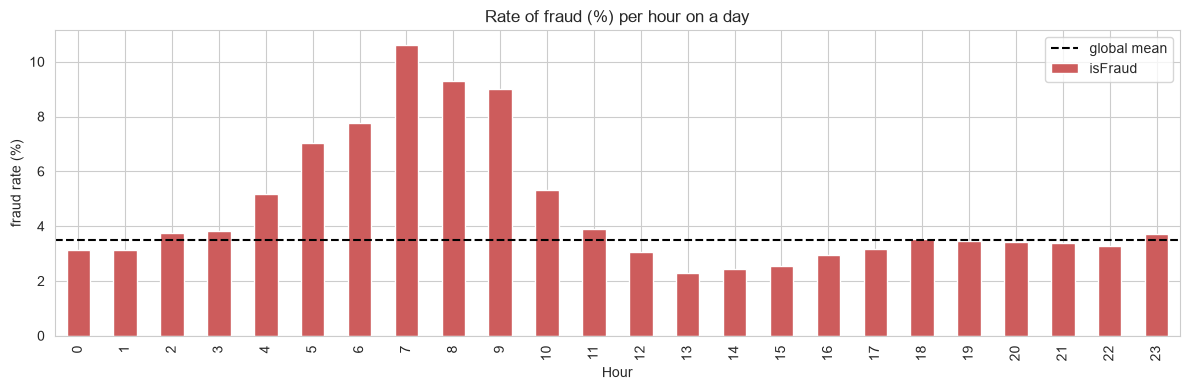

In [7]:
# TransactionDT is delta in secondes
# we convert it in days and hours

df["hour"] = (df["TransactionDT"] / 3600) % 24
df["hour"] = df["hour"].astype(int)

df["day"] = (df["TransactionDT"] / (3600 * 24)) % 7
df["day"] = df["day"].astype(int)

print("TransactionDT interval (secondes) :")
print(f"  min : {df['TransactionDT'].min():,}")
print(f"  max : {df['TransactionDT'].max():,}")
print(f"  time covered : ~{(df['TransactionDT'].max() - df['TransactionDT'].min()) / (3600*24):.0f} jours")

# Rate of fraud per hour on a day
fraud_by_hour = df.groupby("hour")["isFraud"].mean() * 100

plt.figure(figsize=(12, 4))
fraud_by_hour.plot(kind="bar", color="indianred")
plt.title("Rate of fraud (%) per hour on a day")
plt.xlabel("Hour")
plt.ylabel("fraud rate (%)")
plt.axhline(df["isFraud"].mean() * 100, color="black", linestyle="--", label="global mean")
plt.legend()
plt.tight_layout()
plt.show()

## Notes
- Fraud rate shows strong cyclical variation by transaction hour, peaking at ~10.5% (≈3× baseline) in one part of the daily cycle and dropping to ~2.3% in another.
- Transaction time is therefore a valuable predictive feature. Note: the true timezone is unknown, so the peak is characterized by its position in the cycle rather than a literal clock time.

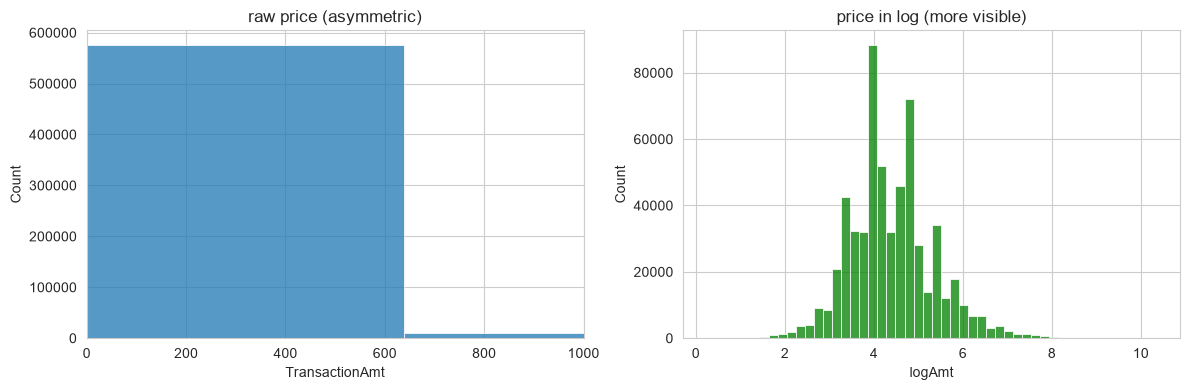

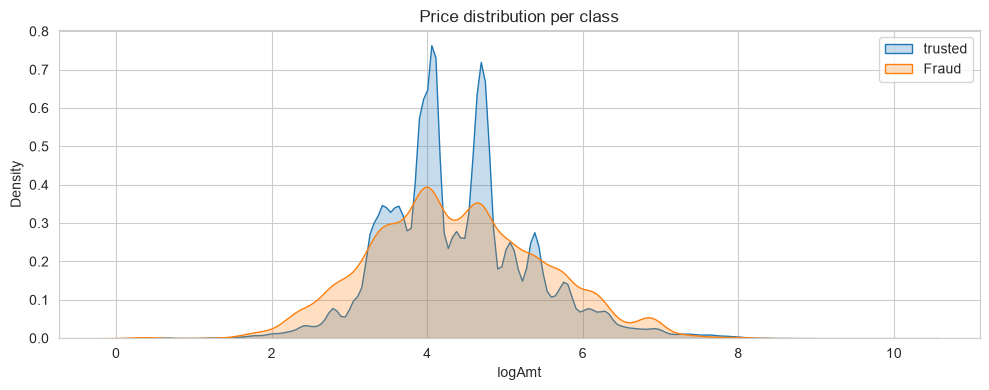

            count        mean         std    min     25%   50%    75%  \
isFraud                                                                 
0        569877.0  134.511665  239.395078  0.251  43.970  68.5  120.0   
1         20663.0  149.244779  232.212163  0.292  35.044  75.0  161.0   

               max  
isFraud             
0        31937.391  
1         5191.000  


In [9]:
# Transactions price
# raw vs log distributions
df["logAmt"] = np.log1p(df["TransactionAmt"])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["TransactionAmt"], bins=50, ax=ax[0])
ax[0].set_title("raw price (asymmetric)")
ax[0].set_xlim(0, 1000)

sns.histplot(df["logAmt"], bins=50, ax=ax[1], color="green")
ax[1].set_title("price in log (more visible)")

plt.tight_layout()
plt.show()

# Comparing the prices : fraud vs trusted
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df[df["isFraud"]==0], x="logAmt", label="trusted", fill=True)
sns.kdeplot(data=df[df["isFraud"]==1], x="logAmt", label="Fraud", fill=True)
plt.title("Price distribution per class")
plt.legend()
plt.tight_layout()
plt.show()

print(df.groupby("isFraud")["TransactionAmt"].describe())

Top 25 empty columns :
id_24    99.196159
id_25    99.130965
id_08    99.127070
id_07    99.127070
id_21    99.126393
id_26    99.125715
id_22    99.124699
id_27    99.124699
id_23    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_03    88.768923
id_04    88.768923
D6       87.606767
id_33    87.589494
D9       87.312290
D8       87.312290
id_10    87.312290
id_09    87.312290
id_30    86.865411
id_32    86.861855
dtype: float64

Columns with  >90% missing values : 12
Columns with >50% missing values : 214
Columns without missing values   : 23


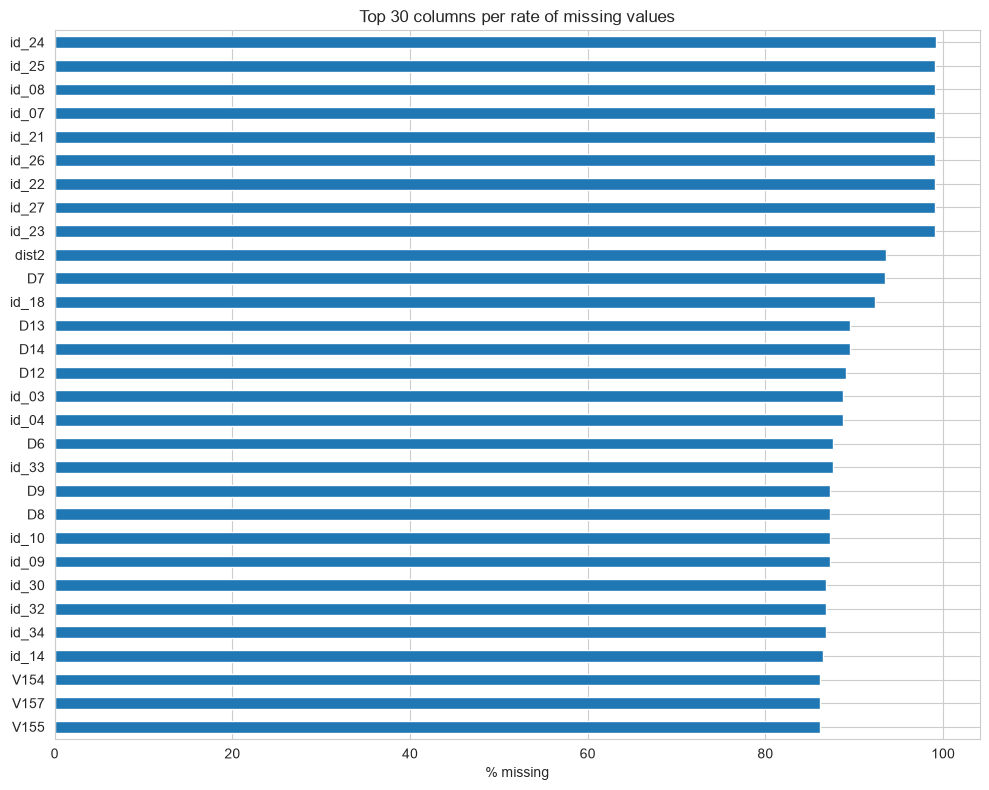

In [10]:
# Percentage of missing vales per column
missing = (df.isnull().mean() * 100).sort_values(ascending=False)

print("Top 25 empty columns :")
print(missing.head(25))

print(f"\nColumns with  >90% missing values : {(missing > 90).sum()}")
print(f"Columns with >50% missing values : {(missing > 50).sum()}")
print(f"Columns without missing values   : {(missing == 0).sum()}")

# Visualization
plt.figure(figsize=(10, 8))
missing.head(30).plot(kind="barh")
plt.title("Top 30 columns per rate of missing values")
plt.xlabel("% missing")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Notes
- The dataset has extensive missingness:
    - 12 columns exceed 90% missing (dropped),
    - 214 exceed 50%,
    - only 23 are fully populated.
- Missingness is largely structural, driven by transactions lacking a matching identity record (left join).
- Strategy:
    - drop near-empty columns,
    - retain missing-indicator flags where absence is informative,
    - keep the clean core,
    - use XGBoost's native NaN handling to avoid aggressive imputation.


ProductCD — 5 distinct values
ProductCD
C    11.687269
S     5.899553
H     4.766231
R     3.782594
W     2.039939
Name: isFraud, dtype: float64

card4 — 4 distinct values
card4
discover            7.728161
visa                3.475610
mastercard          3.433095
american express    2.869837
Name: isFraud, dtype: float64

card6 — 4 distinct values
card6
credit             6.678480
debit              2.426251
charge card        0.000000
debit or credit    0.000000
Name: isFraud, dtype: float64

P_emaildomain — 59 distinct values
P_emaildomain
outlook.com      9.458399
hotmail.com      5.295028
gmail.com        4.354185
icloud.com       3.143450
comcast.net      3.118661
anonymous.com    2.321747
yahoo.com        2.275745
msn.com          2.199413
aol.com          2.181060
att.net          0.743863
Name: isFraud, dtype: float64


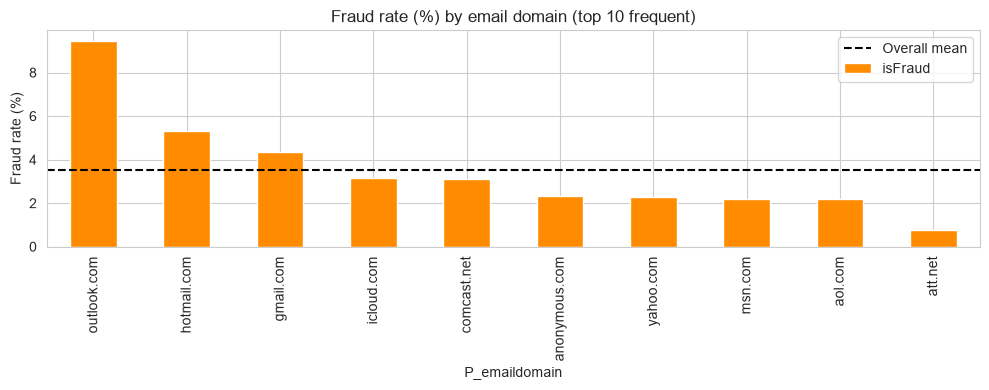

In [11]:
# Key categorical columns to examine
cat_cols = ["ProductCD", "card4", "card6", "P_emaildomain"]

for col in cat_cols:
    print(f"\n{'='*50}")
    print(f"{col} — {df[col].nunique()} distinct values")
    print(f"{'='*50}")
    # Fraud rate per category (top 10 by frequency)
    top = df[col].value_counts().head(10).index
    fraud_rate = df[df[col].isin(top)].groupby(col)["isFraud"].mean() * 100
    print(fraud_rate.sort_values(ascending=False))

# Visualization: fraud rate by email domain (top 10 most frequent)
top_emails = df["P_emaildomain"].value_counts().head(10).index
fraud_email = (
    df[df["P_emaildomain"].isin(top_emails)]
    .groupby("P_emaildomain")["isFraud"].mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
fraud_email.plot(kind="bar", color="darkorange")
plt.title("Fraud rate (%) by email domain (top 10 frequent)")
plt.ylabel("Fraud rate (%)")
plt.axhline(df["isFraud"].mean() * 100, color="black", linestyle="--", label="Overall mean")
plt.legend()
plt.tight_layout()
plt.show()



# Notes
- Categorical signal check:
    - ProductCD (2.0%–11.7% spread),
    - card6 (credit 6.7% vs debit 2.4%),
    - P_emaildomain (up to 9.5% for outlook vs ~2% for others)
show strong fraud-rate variation across categories and are retained as features.
- card4 shows weak variation.
- Rare categories with extreme rates (e.g. "charge card" at 0%) are treated as unreliable due to low volume.

V columns (Vesta engineered) : 339
C columns (counting)         : 14


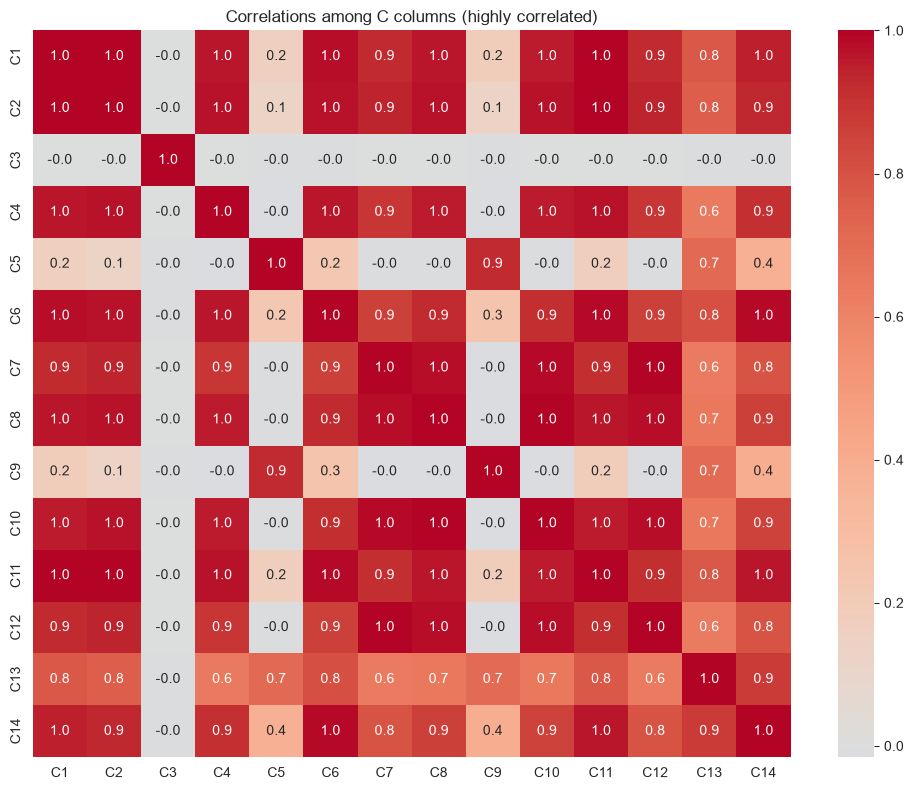

In [12]:
# Identify the groups of anonymized columns
v_cols = [c for c in df.columns if c.startswith("V")]
c_cols = [c for c in df.columns if c.startswith("C")]

print(f"V columns (Vesta engineered) : {len(v_cols)}")
print(f"C columns (counting)         : {len(c_cols)}")

# Correlations among the C columns (small enough to visualize)
corr = df[c_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".1f")
plt.title("Correlations among C columns (highly correlated)")
plt.tight_layout()
plt.show()

# Notes
- The 14 C (counting) columns are highly multicollinear — a large block (C1, C2, C4, C6, C8, C10–C12, C14) correlates at 0.9–1.0, indicating heavy redundancy. C3 is independent, and C5/C9 form a separate pair.
- Effective information is ~3–4 distinct signals.
- Plan:
    - reduce redundancy via subset selection (keep representatives like C1, C3, C5) or PCA. XGBoost tolerates correlation, so this is an optimization for speed and interpretability rather than a hard requirement.

In [13]:
# Numeric summary to document your decisions
print("="*55)
print("EDA SUMMARY")
print("="*55)
print(f"Total transactions        : {df.shape[0]:,}")
print(f"Number of features        : {df.shape[1]}")
print(f"Fraud rate                : {df['isFraud'].mean()*100:.2f} %")
print(f"Period covered            : ~{(df['TransactionDT'].max()-df['TransactionDT'].min())/(3600*24):.0f} days")
print(f"Columns >90% missing      : {(df.isnull().mean()>0.9).sum()}")
print(f"V columns (anonymized)    : {len(v_cols)}")
print(f"C columns (counting)      : {len(c_cols)}")
print("="*55)

EDA SUMMARY
Total transactions        : 590,540
Number of features        : 437
Fraud rate                : 3.50 %
Period covered            : ~182 days
Columns >90% missing      : 12
V columns (anonymized)    : 339
C columns (counting)      : 14
